 TASK 4: Sentiment Analysis

● Analyze text data to classify it as positive, negative or neutra.

● 2. Use NLP techniques and lexicons to detect specific emotions.

● 3. Apply analysis on data from sources like Amazon reviews, social media, and news sites.

● 4. Understand public opinion and trends through sentiment patterns.

● 5. Use results to inform marketing, product development, or social insights

In [ ]:
from transformers import pipeline

# Save the model locally
model_name = "siebert/sentiment-roberta-large-english"
save_path = r"C:\Users\addis\Downloads\etl"


In [ ]:
# pip install --upgrade pip

In [ ]:
# Load the pipeline and save the model
sentiment_analysis = pipeline("sentiment-analysis", model=model_name)
sentiment_analysis.save_pretrained(save_path)

# Reuse the saved model
sentiment_analysis_reuse = pipeline("sentiment-analysis", model=save_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cpu
Device set to use cpu


In [ ]:
# Test the reused model
# play with the parameter and see if it works

result = sentiment_analysis_reuse("I love this app")
print(result)

[{'label': 'POSITIVE', 'score': 0.9988906979560852}]


In [ ]:
#removing wildcharacter and cleaning the content column by casting to a str
dataapp_df['content_new']= dataapp_df['content'].astype('str')

In [ ]:
dataapp_df['result'] =dataapp_df['content_new'].apply(lambda x: sentiment_analysis_reuse(x, truncation=True, max_length=512))

In [ ]:
# spliting the result into sentiment and score
dataapp_df['sentiment'] = dataapp_df['result'].apply(lambda x: (x[0]['label']))
dataapp_df['score'] = dataapp_df['result'].apply(lambda x: (x[0]['score']))

In [ ]:
dataapp_df[['content','score','sentiment']]

,content,score,sentiment
0,this app they are thief I send 3k into my acco...,0.999461,NEGATIVE
1,they are scammers run away from them. I funded...,0.999504,NEGATIVE
2,"Your networking is bad, and it doesn't seem li...",0.999510,NEGATIVE
3,since I upgraded this app I can't even login a...,0.999507,NEGATIVE
4,Very poor application,0.999493,NEGATIVE
...,...,...,...
56,I have downloaded the app but I find it hard t...,0.999322,NEGATIVE
57,Data is good,0.998624,POSITIVE
58,Convenient and Reliable! DataApp has made life...,0.998933,POSITIVE
59,We Love DataApp,0.998596,POSITIVE


In [ ]:
dataapp_df.value_counts('sentiment', normalize = True)

,proportion
sentiment,
NEGATIVE,0.540984
POSITIVE,0.459016


/tmp/ipython-input-2384600679.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'sentiment', data = dataapp_df, palette=["red", "blue"])


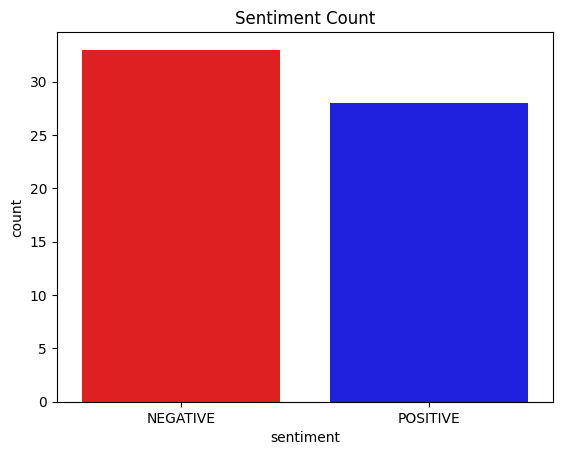

In [ ]:
sns.countplot(x = 'sentiment', data = dataapp_df, palette=["red", "blue"])
plt.title('Sentiment Count')
plt.show()


## Topic modeling

In [ ]:
#generate a series for the reviews
feature_google=dataapp_df['content']
print(feature_google.size)
feature_google.head()

61


,content
0,this app they are thief I send 3k into my acco...
1,they are scammers run away from them. I funded...
2,"Your networking is bad, and it doesn't seem li..."
3,since I upgraded this app I can't even login a...
4,Very poor application


In [ ]:
# Import the necessary libraries
!pip install textblob

import textblob
from textblob import TextBlob


# Define a function to translate the text to English
def translate_to_en(text):
    blob = TextBlob(str(text))
    try:
        return str(blob.translate(to='en'))
    except:
        return str(text)

# Apply the translate_to_en function to the 'review' column of the DataFrame
feature_google = feature_google.apply(translate_to_en)

# Print the top 5 rows of the DataFrame with the new 'review_en' column
print(feature_google.head())


0    this app they are thief I send 3k into my acco...
1    they are scammers run away from them. I funded...
2    Your networking is bad, and it doesn't seem li...
3    since I upgraded this app I can't even login a...
4                                Very poor application
Name: content, dtype: object


In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 5.9 MB/s eta 0:00:00


In [ ]:
from bertopic import BERTopic

topic_model = BERTopic()
topics, probs = topic_model.fit_transform(feature_google.astype(str))

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4,-1_very_poor_in_issues,"[very, poor, in, issues, god, company, hoped, ...","[Very poor application, The app is very fast i..."
1,0,27,0_app_the_to_it,"[app, the, to, it, and, my, money, you, they, is]","[Your networking is bad, and it doesn't seem l..."
2,1,18,1_good_love_nice_app,"[good, love, nice, app, really, very, joy, all...","[Good, Good app, Good app]"
3,2,12,2_data_is_dataapp_and,"[data, is, dataapp, and, this, for, the, best,...",[Data is the best App Ever They Data price is ...


In [ ]:
# the data to excel
output_file = 'playstore_reviews.xlsx'
dataapp_df.to_excel(output_file, index=False)